# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-17 10:48:27,941::INFO::settings.py::Setting loglevel to INFO
2025-02-17 10:48:27,942::INFO::settings.py::Setting stores to {}
2025-02-17 10:48:27,943::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-17 10:48:27,944::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-17 10:48:27,945::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-17 10:48:27,945::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-17 10:48:27,946::INFO::settings.py::Setting database.user to celia
2025-02-17 10:48:27,946::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-17 10:48:28,128::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-17 10:48:28,233::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:28,645::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:28,645::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,102::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,102::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,249::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,249::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,570::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,570::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,890::INFO::table.py::could not log event in table ~log
2025-02-17 10:48:29,890::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [5]:
# To be run with Figure 2 notebook, else see how to load the data in Figure 2 notebook
niell_data = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_dual.pkl")

big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)
#big_df = pd.read_pickle("big_df_contrast_dual.pkl")
big_df = big_df [big_df.iti ==0.0]

In [6]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

In [7]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=regression.model_labels, per_mouse=True)

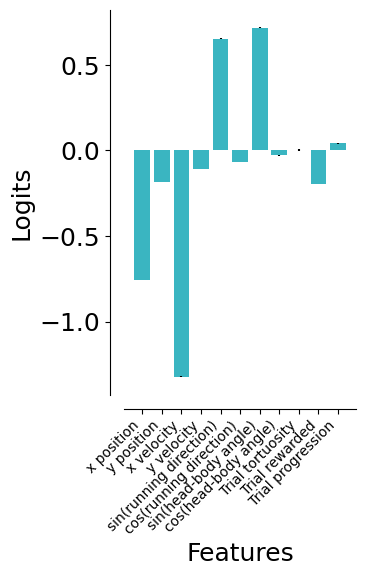

In [8]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1"
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(regression.model_labels))) 
ax.set_xticklabels(regression.clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "figure3_dual_occluder_model_logits.svg", transparent=False)

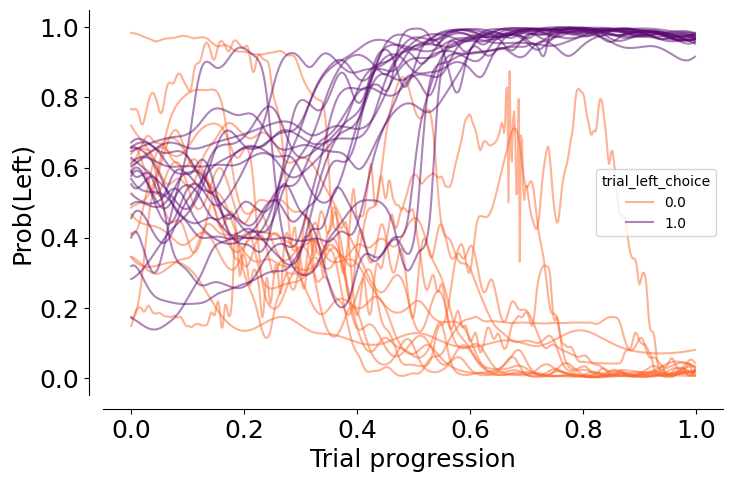

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

group = df_model[(df_model.dataset == df_model.dataset.unique()[15])]

trials = [94 , 15,  66, 170, 224, 195,  56, 203,  88, 239, 113,  91, 186, 248, 109, 164,
          188,  60, 229, 182, 156, 197,  52,  45, 110, 156, 190,  22, 210,  24,  51,  78, 
          239,  97,  24, 176, 168, 184, 123, 156]

group = group [group.trial.isin(np.array(trials))]
sns.lineplot(
        data=group,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        errorbar=None,
        estimator=None,
        units="trial",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax
    )
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_dual_occluder_dynamic_decision_variable.svg", transparent=True)

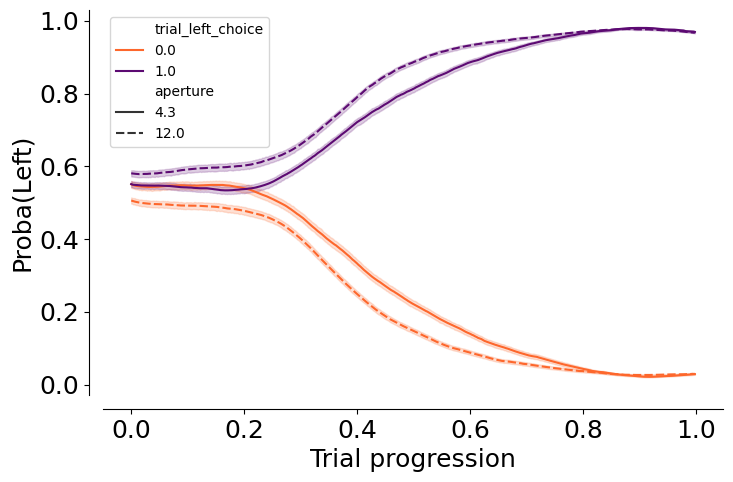

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        style="aperture",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=1, ax=ax
    )
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.svg", transparent=True)

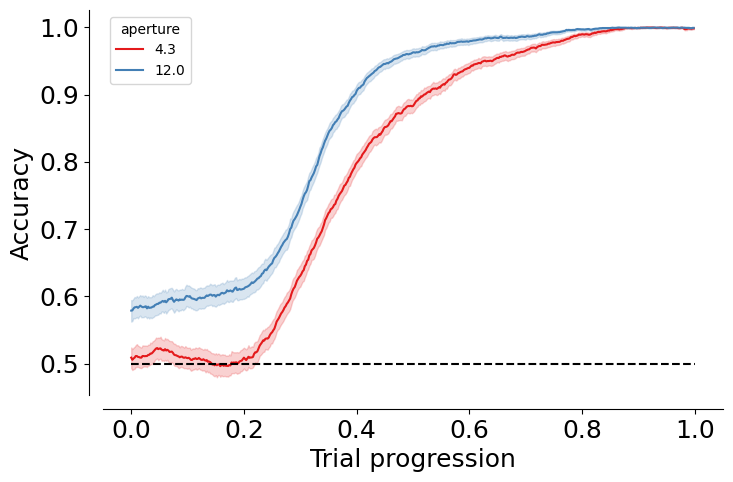

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="accuracy",
        hue="aperture",
        palette= plotting.colors_aperture,
        sort=False, alpha=1, ax=ax
    )
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_dual_occluder_model_accuracy.svg", transparent=True)

In [12]:
df_model["trial_length_bin"] = pd.cut(df_model["trial_length"], bins=50)  # Adjust bins as needed
df_anova = df_model.groupby(["dataset", "aperture", "trial_length_bin"], as_index=False)["accuracy"].mean()

print(AnovaRM(data=df_anova, depvar="accuracy", 
              subject="dataset", within=["aperture", "trial_length_bin"]).fit())

                           Anova
                          F Value   Num DF   Den DF  Pr > F
-----------------------------------------------------------
aperture                   50.3713  1.0000   38.0000 0.0000
trial_length_bin          970.7786 49.0000 1862.0000 0.0000
aperture:trial_length_bin  16.6714 49.0000 1862.0000 0.0000



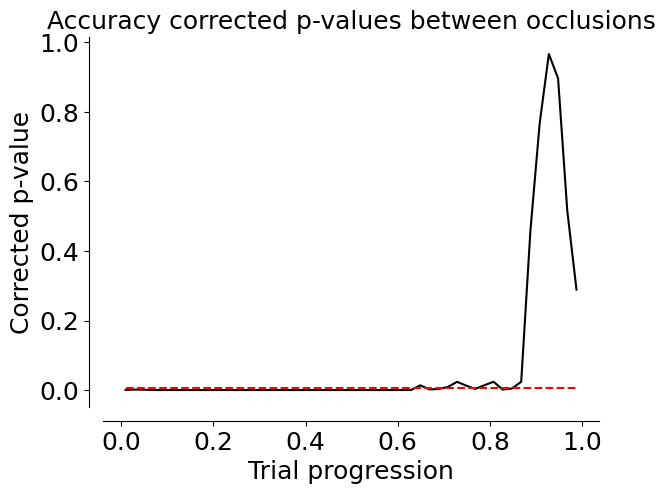

In [ ]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin==i]
    t= ttest_ind(section[section.aperture==section.aperture.unique()[0]].accuracy, section[section.aperture==section.aperture.unique()[1]].accuracy)
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.005, xmin=p_value_df.segment.min(), xmax=p_value_df.segment.max(), color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Accuracy corrected p-values between occlusions")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_dual_occluder_model_accuracy_pvalue.svg", transparent=True)


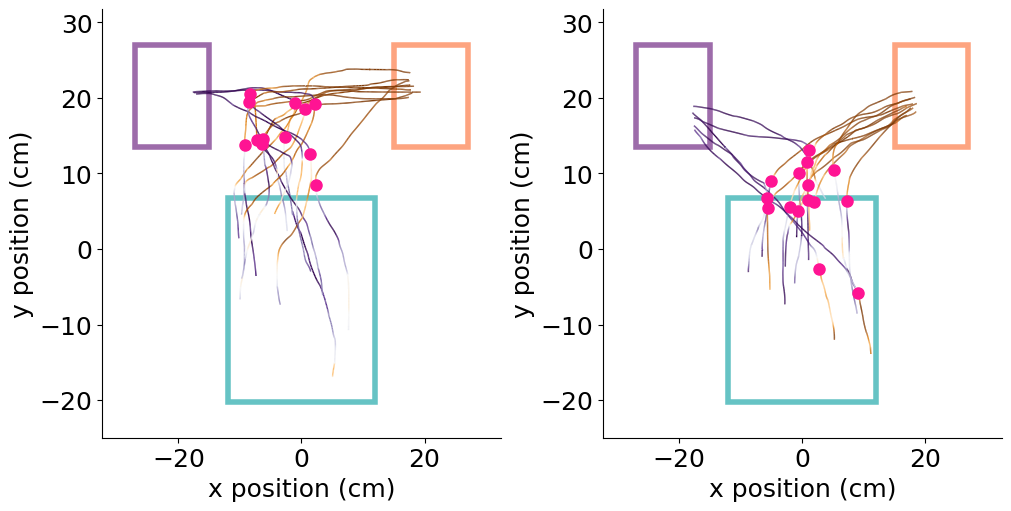

In [14]:
df_model["session"] = df_model["dataset"]
df_model["trial_L_choice"] = df_model["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)
fig, ax = plt.subplots(1, len(df_model.aperture.unique()), figsize=(10, 5), constrained_layout=True)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45,  19,  62, 61, 45,  85, 41, 43, 41, 50, 75, 24, 69, 84,
           74,  10] + [63, 30, 78, 47, 33, 5,  17, 9,
          47,  30, 99, 11, 12, 15]


for i, aperture in enumerate(df_model.aperture.unique()):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[(decision_points.dataset == session_to_plot) & (decision_points.aperture == aperture)],
        color=decision_color,
        trials=trials,
        ax=ax[i],
    )
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
plt.savefig(save_fig_path + "figure3_dual_occluder_decision_points_trajectories.svg", transparent=True)

2025-02-17 10:54:50,778::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,778::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,788::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,788::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,860::INFO::category.py::Using categorical un

2025-02-17 10:54:50,924::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,924::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,932::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,932::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-17 10:54:50,949::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-12.591714479533158, pvalue=3.9185467710117e-15, df=38)


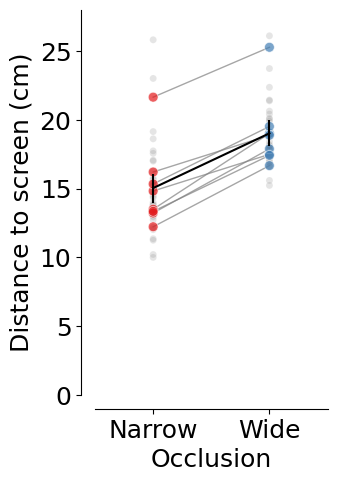

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(decision_points, 
                                                 label_parameter="y",  
                                                 ax=ax, 
                                                 cmap=plotting.colors_aperture,
                                                 per_mouse=True)
ax.set_xlim(-.5,1.5)
ax.set_ylim(0,28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0,1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([],[], frameon=False)

plt.savefig(save_fig_path + "figure3_dual_occluder_decision_points_distance.svg", transparent = True)

In [16]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)["y"].mean()
anova_rm = AnovaRM(decision_points, depvar='y', subject='dataset', within=['aperture'])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                 Anova
         F Value  Num DF  Den DF Pr > F
---------------------------------------
aperture 158.5513 1.0000 38.0000 0.0000



In [17]:
# parameter = "y"
# thresholds = [0.1, 0.3, 0.5, 0.7, 0.9] # that's the uncertainty threshold of the model
# diffs = []
# for i in thresholds:
#     decision_points = regression.find_decision_point(df_model, threshold_uncertainty=i)
    
#     aperture_means = decision_points.groupby(["mouse_name", "dataset", "aperture"]).mean().groupby(["aperture"]).mean()[parameter]
#     diffs.append(aperture_means.iloc[0] - aperture_means.iloc[-1])
    
# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# ax.plot(thresholds, diffs, color="k")
# ax.set_xlabel("Threshold")
# ax.set_ylabel("Diff distance to screen (cm)")